# Exercise 2 — Classification Metrics

## Part A: Understanding Model Evaluation

In classification problems, accuracy alone is not always enough.

A model may appear “good” while still making important mistakes.

In this exercise, we will learn how to evaluate classification models using:

* accuracy
* precision
* recall
* F1-score
* confusion matrix

### Example Problem

Imagine we are building a spam detector.

The model predicts:

`1 = spam`

`0 = not spam`

### Step 1 — Real Labels vs Predictions

In [7]:
import numpy as np

# True labels
y_true = np.array([
    1,1,1,1,1,
    0,0,0,0,0
])

# Model predictions
y_pred = np.array([
    0,0,1,0,1,
    1,0,1,0,0
])

### Step 2 — Compute the Confusion Matrix

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[3 2]
 [3 2]]


### Understanding the Confusion Matrix

Where:

* TP = true positives
* TN = true negatives
* FP = false positives
* FN = false negatives

### Visualize the Confusion Matrix

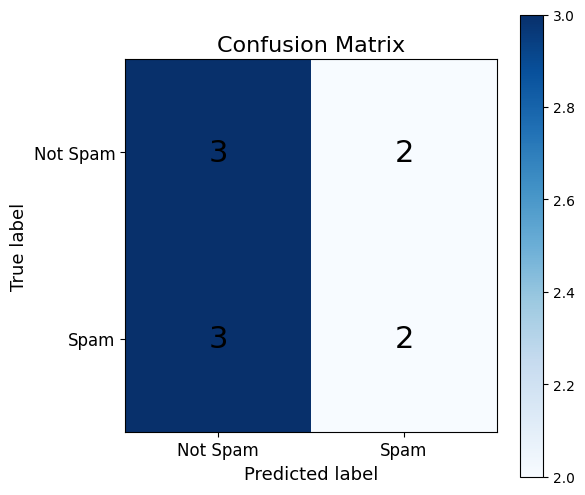

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

# Axis labels
classes = ["Not Spam", "Spam"]

plt.xticks([0,1], classes, fontsize=12)
plt.yticks([0,1], classes, fontsize=12)

# Numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=22,
            color="black"
        )

# Labels
plt.xlabel("Predicted label", fontsize=13)
plt.ylabel("True label", fontsize=13)

plt.title("Confusion Matrix", fontsize=16)

plt.colorbar()

plt.show()

### Step 3 — Compute Metrics

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")

Accuracy : 0.50
Precision: 0.50
Recall   : 0.40
F1-score : 0.44


### What Do These Metrics Mean?

#### Accuracy
How many predictions were correct overall?
    - Answer: 8

Precision
When the model predicts SPAM, how often is it correct?
    - Answer: 80% of the time

Recall
How many real spam messages did the model find?
    - Answer: 4 messages

F1-score
Balance between precision and recall


Questions

1. Is accuracy always enough?
    - No. The intuitive meaning of accuracy is "The percentage of predictions that are correct". It tells us nothing about how many mistakes were made by the model, so we don't know for sure if model is predicting well.
2. What happens if classes are imbalanced?
    - Then accuracy becomes misleading. If 99% of the email were spam and 1% is not, then a model that always predict "spam" would have a very high accuracy, or if 99% were not spam then the model is an absolute failure.
3. Why might high accuracy still be misleading?
    - As explained, classes might be imbalanced, and accuracy tells us nothing about the mistakes of the model.
4. In medical diagnosis, which is worse:
    * false positive?
    * false negative?
    - False negative is much worse because a patient who is sick might be predicted as healthy.
5. Which metric would matter most for:
    * spam filtering?
        - Answer: Precision matters because we don't want to get the "not spam" emails (which might be important emails) being predicted as "spam" emails
    * fraud detection?
        - Answer: Recall matters, its intuitive meaning is "The percentage of positive labeled instances that were predicted as positive". We want the fraud to be detected as much as possible.
    * disease detection?
        - Answer: Recall matters, for the same logic. We want to recognizes as much sick people as possible.

## Part B — Try Your Own Predictions

Modify: `y_pred`

Then rerun the notebook and observe:

* how the confusion matrix changes
* how the metrics change
* which mistakes increase or decrease

## Bonus Challenge

Create:

1. a model with:
    * high precision
    * low recall
2. a model with:
    * high recall
    * low precision

Explain the difference.